# 1. Clone & Setup

**IMPORTANT NOTE:** Make sure to check the cloned branch on `computer-vision-underwater-image-enhancer` repositories.

In [1]:
%%bash
R=/kaggle/working/computer-vision-underwater-image-enhancer
[ -d $R ] || git clone -q -b feature/benchmark-batch-enhance-ruod --single-branch https://github.com/bao-nguyen-quoc/computer-vision-underwater-image-enhancer $R
git -C $R pull -q
bash $R/enhancers/setup.sh

torch 2.11.0+cu128 | Tesla T4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

Downloading...
From: https://drive.google.com/uc?id=1kHOPSUObw7FafI6_xgaD9kCZ5U5JzIsc
To: /kaggle/working/computer-vision-SCNet/weights/scnet.pth
100%|██████████| 62.2M/62.2M [00:01<00:00, 42.4MB/s]


# 2. Optional verification

## 1. Enhance samples by 2 model (Semi-URI & SCNet)

In [2]:
%%bash
R=/kaggle/working/computer-vision-underwater-image-enhancer
python $R/enhancers/enhance_semiuir.py --repo /kaggle/working/computer-vision-Semi-UIR --input $R/samples/test_img.png --output /kaggle/working/out_semiuir
python $R/enhancers/enhance_scnet.py --repo /kaggle/working/computer-vision-SCNet --input $R/samples/test_img.png --output /kaggle/working/out_scnet

samples/test_img.png: 4.39s
samples/test_img.png: 0.62s


## 2. Verify after enhancement

/kaggle/working/out_semiuir: checked 1 images
/kaggle/working/out_scnet: checked 1 images
ALL OK


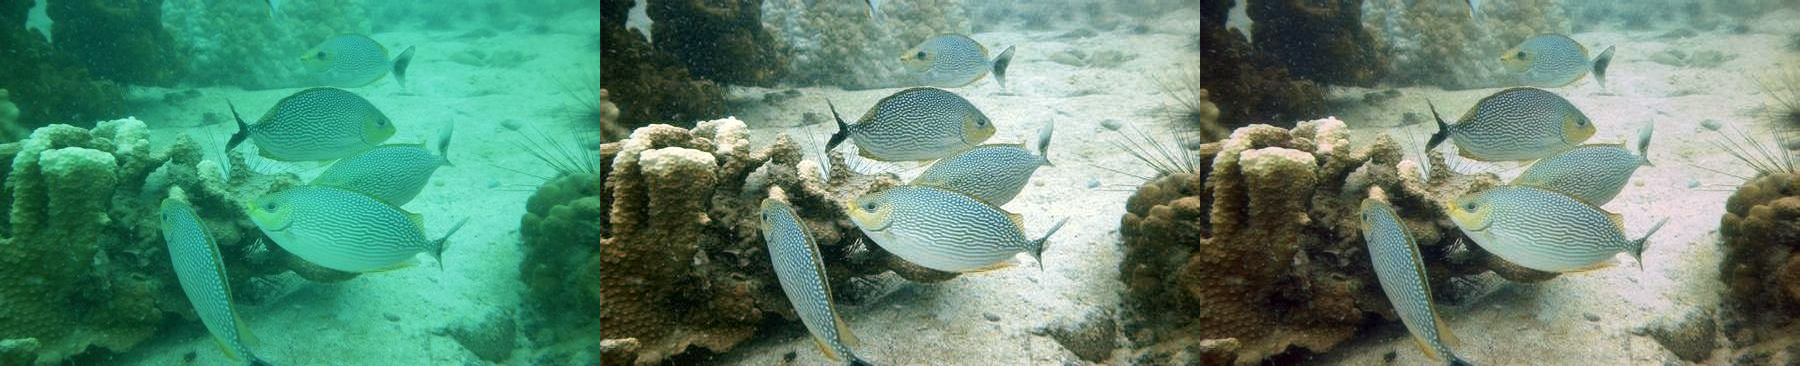

In [3]:
import numpy as np
from PIL import Image
R = '/kaggle/working/computer-vision-underwater-image-enhancer'
!python {R}/enhancers/check_outputs.py --orig {R}/samples --out /kaggle/working/out_semiuir /kaggle/working/out_scnet
paths = [f'{R}/samples/test_img.png', '/kaggle/working/out_semiuir/test_img.png', '/kaggle/working/out_scnet/test_img.png']
display(Image.fromarray(np.hstack([np.asarray(Image.open(p).convert('RGB')) for p in paths])))   # Origin | Semi-UIR | SCNet

# 3. PSNR / SSIM on test dataset of UIED

## 3.1. Enhance on UIEB test

In [2]:
import os

test_path = "/kaggle/input/datasets/phanlvnminh/ruod640/benchmark/UIEBD/test"
print(os.path.exists(test_path))
print(os.listdir(test_path)) # Expected: ['image', 'label']

True
['label', 'image']


In [3]:
%%bash
set -e
IN=/kaggle/input/datasets/phanlvnminh/ruod640/benchmark/UIEBD/test/image
OUT=/kaggle/working/out_benchmark
E=/kaggle/working/computer-vision-underwater-image-enhancer/enhancers

python $E/enhance_scnet.py --repo /kaggle/working/computer-vision-SCNet --input $IN --output $OUT/uieb_scnet
python $E/enhance_semiuir.py --repo /kaggle/working/computer-vision-Semi-UIR --input $IN --output $OUT/uieb_semiuir
python $E/check_outputs.py --orig $IN --out $OUT/uieb_semiuir $OUT/uieb_scnet

image/701.jpg: 1.86s
image/702.jpg: 0.27s
image/703.jpg: 0.35s
image/705.jpg: 0.27s
image/709.jpg: 0.22s
image/712.jpg: 0.22s
image/713.jpg: 0.28s
image/717.jpg: 0.16s
image/720.jpg: 0.43s
image/721.jpg: 0.22s
image/729.jpg: 0.34s
image/734.jpg: 0.22s
image/735.jpg: 0.23s
image/736.jpg: 0.30s
image/738.jpg: 0.20s
image/740.jpg: 0.31s
image/742.jpg: 0.27s
image/743.jpg: 0.22s
image/745.jpg: 0.22s
image/746.jpg: 0.26s
image/751.jpg: 0.40s
image/753.jpg: 0.23s
image/755.jpg: 0.27s
image/756.jpg: 0.22s
image/760.jpg: 0.28s
image/762.jpg: 0.34s
image/763.jpg: 0.22s
image/765.jpg: 0.10s
image/766.jpg: 0.16s
image/767.jpg: 0.13s
image/769.jpg: 0.37s
image/770.jpg: 0.10s
image/771.jpg: 0.38s
image/772.jpg: 0.47s
image/776.jpg: 0.14s
image/777.jpg: 0.11s
image/780.jpg: 0.27s
image/781.jpg: 0.26s
image/782.jpg: 0.27s
image/783.jpg: 0.35s
image/785.jpg: 0.09s
image/789.jpg: 0.27s
image/791.jpg: 0.27s
image/793.jpg: 0.11s
image/794.jpg: 0.26s
image/797.jpg: 0.11s
image/798.jpg: 0.11s
image/801.jpg

## 3.2. Calculate PSNR/SSIM

In [4]:
D   = "/kaggle/input/datasets/phanlvnminh/ruod640/benchmark/UIEBD/test"
IN  = f"{D}/image"
OUT = "/kaggle/working/out_benchmark"
E   = "/kaggle/working/computer-vision-underwater-image-enhancer/enhancers"

!python {E}/eval_uieb.py --ref {D}/label --pred raw={IN} scnet={OUT}/uieb_scnet semiuir={OUT}/uieb_semiuir


| Method | Number of images | PSNR | SSIM |
|---|---|---|---|
| raw | 90 | 17.90 | 0.7759 |
| scnet | 90 | 22.43 | 0.8787 |
| semiuir | 90 | 24.21 | 0.8857 |
